In [2]:
import pandas as pd

df = pd.read_csv("datasets/01_retail_sales.csv")



In [3]:
df.head()

,order_id,order_date,region,category,product,sales_channel,customer_segment,units_sold,unit_price,discount_pct,revenue,cost,profit,payment_method,returned
0,ORD-000001,2025-03-31,Central,Clothing,Winter Jacket,Marketplace,Consumer,3,136.24,0,408.72,305.45,103.27,Wallet,No
1,ORD-000002,2025-06-24,West,Electronics,Wireless Headphones,Marketplace,Consumer,1,82.46,10,74.21,56.32,17.89,Card,No
2,ORD-000003,2024-08-01,West,Electronics,Smart Watch,Marketplace,Consumer,2,162.27,25,243.41,182.23,61.18,Bank Transfer,No
3,ORD-000004,2025-11-10,West,Clothing,Winter Jacket,Online,Consumer,1,118.72,15,100.91,86.83,14.08,Wallet,No
4,ORD-000005,2025-08-03,South,Electronics,Wireless Headphones,Online,Corporate,4,81.29,20,260.13,224.21,35.92,Card,No


In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   order_date        10000 non-null  object 
 2   region            10000 non-null  object 
 3   category          10000 non-null  object 
 4   product           10000 non-null  object 
 5   sales_channel     10000 non-null  object 
 6   customer_segment  10000 non-null  object 
 7   units_sold        10000 non-null  int64  
 8   unit_price        10000 non-null  float64
 9   discount_pct      10000 non-null  int64  
 10  revenue           10000 non-null  float64
 11  cost              10000 non-null  float64
 12  profit            10000 non-null  float64
 13  payment_method    10000 non-null  object 
 14  returned          10000 non-null  object 
dtypes: float64(4), int64(2), object(9)
memory usage: 1.1+ MB
None


In [6]:
print(df.columns)

Index(['order_id', 'order_date', 'region', 'category', 'product',
       'sales_channel', 'customer_segment', 'units_sold', 'unit_price',
       'discount_pct', 'revenue', 'cost', 'profit', 'payment_method',
       'returned'],
      dtype='object')


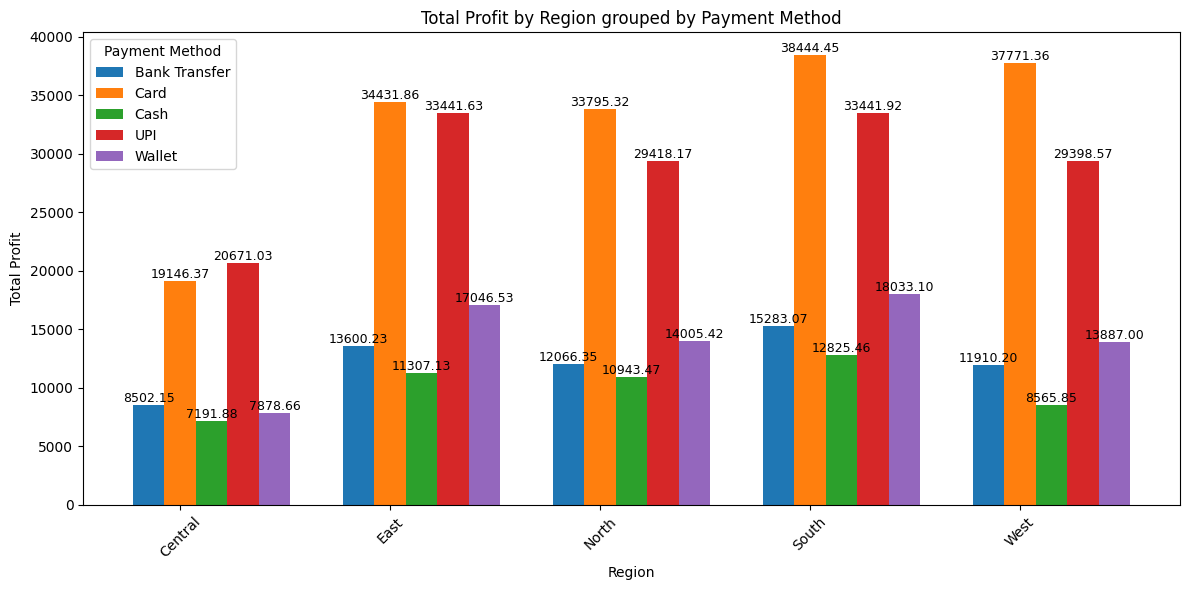

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Grouping: sum of profit by region and payment_method
grouped = df.groupby(['region', 'payment_method'])['profit'].sum().unstack()

# Plot setup
plt.figure(figsize=(12, 6))

regions = grouped.index
payment_methods = grouped.columns
x = np.arange(len(regions))
width = 0.15  # width of each bar

# Plot each payment method as a separate bar series
for i, pm in enumerate(payment_methods):
    bars = plt.bar(x + i*width, grouped[pm], width, label=pm)

    # Add data labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9
        )

# Labels and formatting
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total Profit by Region grouped by Payment Method")
plt.xticks(x + width, regions, rotation=45)
plt.legend(title="Payment Method")
plt.tight_layout()

plt.show()


In [8]:
print(df.dtypes)

order_id             object
order_date           object
region               object
category             object
product              object
sales_channel        object
customer_segment     object
units_sold            int64
unit_price          float64
discount_pct          int64
revenue             float64
cost                float64
profit              float64
payment_method       object
returned             object
dtype: object


In [9]:
print("Total Profit:", df['profit'].sum())


Total Profit: 493007.18


In [11]:
print(df.groupby('region')['profit'].sum())
resultf=df.groupby('region')['profit'].sum()


region
Central     63390.09
East       109827.38
North      100228.73
South      118028.00
West       101532.98
Name: profit, dtype: float64


region
Central     63390.09
East       109827.38
North      100228.73
South      118028.00
West       101532.98
Name: profit, dtype: float64


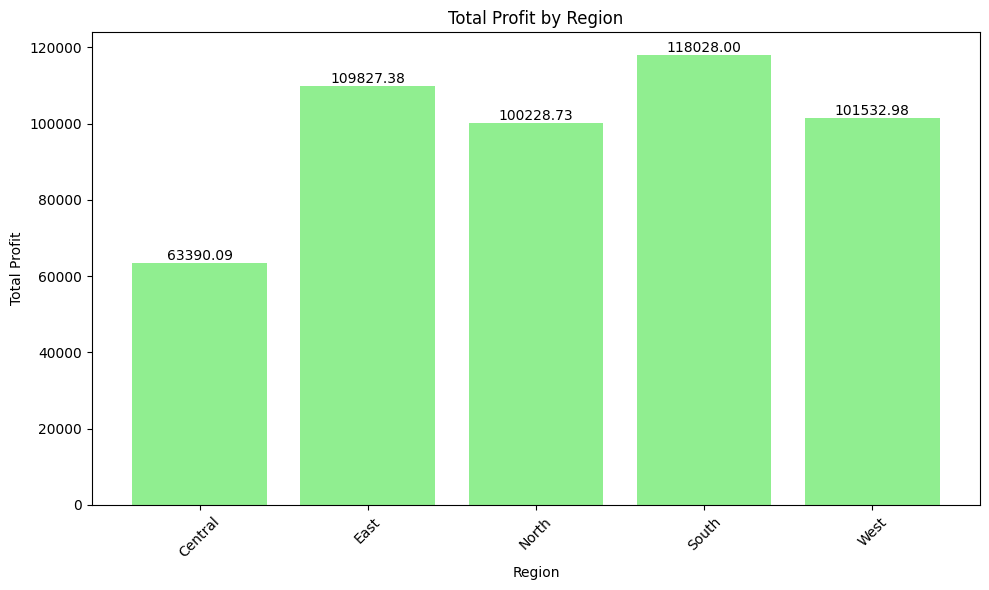

In [14]:
print(resultf)
import matplotlib.pyplot as plt

# Grouping and summing profit by region


# Plotting
plt.figure(figsize=(10,6))
bars=plt.bar(resultf.index, resultf.values, color='lightgreen')

plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total Profit by Region")
plt.xticks(rotation=45)


# Adding data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # X position (center of bar)
        height,                            # Y position (top of bar)
        f'{height:.2f}',                    # Label text
        ha='center', va='bottom', fontsize=10
    )
plt.tight_layout()

plt.show()
